<h1> Training Results Analysis | MNIST </h1>

<h2> Gaussian Init - SGD</h2>

In [1]:
import h5py
import numpy as np
import polars as pl
import numpy as np
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri, numpy2ri, default_converter
import rpy2.robjects as ro
from data.h5pydb import load_h5_as_polars_v2
import matplotlib.pyplot as plt 
import seaborn as sns 

In [11]:
fc10_gaussian_none_sgd_path = r"/Users/janikwahrheit/Library/CloudStorage/OneDrive-Persönlich/01_Studium/01_Bachelor/Bachelorarbeit/Code/data/training_results/fc10_gaussian_none_sgd_log.h5"
fc10_gaussian_lasso_sgd_path = r"/Users/janikwahrheit/Library/CloudStorage/OneDrive-Persönlich/01_Studium/01_Bachelor/Bachelorarbeit/Code/data/training_results/fc10_gaussian_lasso_sgd_log.h5"
fc10_gaussian_remore_sgd_path= r"/Users/janikwahrheit/Library/CloudStorage/OneDrive-Persönlich/01_Studium/01_Bachelor/Bachelorarbeit/Code/data/training_results/fc10_gaussian_remore_sgd_log.h5"
fc10_gaussian_remore_sgd_path_v2= r"/Users/janikwahrheit/Library/CloudStorage/OneDrive-Persönlich/01_Studium/01_Bachelor/Bachelorarbeit/Code/data/training_results/fc10_gaussian_remore_sgd_v2_log.h5"
fc10_gaussian_hill_sgd_path = r"/Users/janikwahrheit/Library/CloudStorage/OneDrive-Persönlich/01_Studium/01_Bachelor/Bachelorarbeit/Code/data/training_results/fc10_gaussian_hill_sgd_log.h5"
fc10_gaussian_hill_sum_sgd_path = r"/Users/janikwahrheit/Library/CloudStorage/OneDrive-Persönlich/01_Studium/01_Bachelor/Bachelorarbeit/Code/data/training_results/fc10_gaussian_hill_sum_sgd_log.h5"
fc10_gaussian_hill_sum_weighted_sgd_path = r"/Users/janikwahrheit/Library/CloudStorage/OneDrive-Persönlich/01_Studium/01_Bachelor/Bachelorarbeit/Code/data/training_results/fc10_gaussian_hill_sum_weighted_sgd_log.h5"

In [3]:
df_fc10_gaussian_none_sgd  = load_h5_as_polars_v2(fc10_gaussian_none_sgd_path)

In [4]:
df_fc10_gaussian_lasso_sgd = load_h5_as_polars_v2(fc10_gaussian_lasso_sgd_path)

In [5]:
df_fc10_gaussian_remore_sgd_v2 = load_h5_as_polars_v2(fc10_gaussian_remore_sgd_path_v2)

In [6]:
df_fc10_gaussian_remore_sgd = load_h5_as_polars_v2(fc10_gaussian_remore_sgd_path)

In [7]:
df_fc10_gaussian_hill_sgd = load_h5_as_polars_v2(fc10_gaussian_hill_sgd_path)

In [8]:
df_fc10_gaussian_hill_sum_sgd = load_h5_as_polars_v2(fc10_gaussian_hill_sum_sgd_path)

In [12]:
df_fc10_gaussian_hill_sum_weighted_sgd = load_h5_as_polars_v2(fc10_gaussian_hill_sum_weighted_sgd_path)

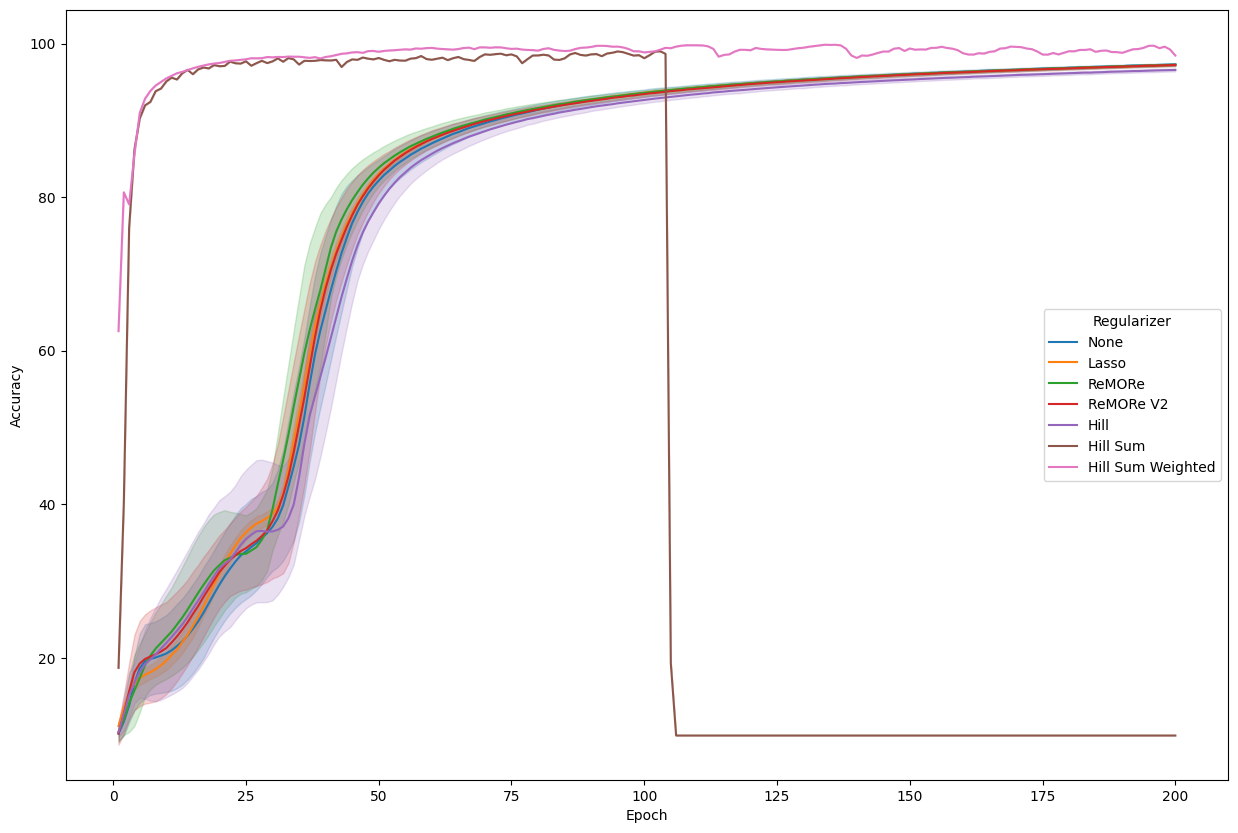

In [15]:
fig, ax = plt.subplots(figsize=(15, 10))

sns.lineplot(x="epoch", y="accuracy", data=df_fc10_gaussian_none_sgd, label="None", ax=ax, errorbar="sd")
sns.lineplot(x="epoch", y="accuracy", data=df_fc10_gaussian_lasso_sgd, label="Lasso", ax=ax)
sns.lineplot(x="epoch", y="accuracy", data=df_fc10_gaussian_remore_sgd, label="ReMORe", ax=ax, errorbar="sd")
sns.lineplot(x="epoch", y="accuracy", data=df_fc10_gaussian_remore_sgd_v2, label="ReMORe V2", ax=ax, errorbar="sd")
sns.lineplot(x="epoch", y="accuracy", data=df_fc10_gaussian_hill_sgd, label="Hill", ax=ax, errorbar="sd")
sns.lineplot(x="epoch", y="accuracy", data=df_fc10_gaussian_hill_sum_sgd, label="Hill Sum", ax=ax, errorbar="sd")
sns.lineplot(x="epoch", y="accuracy", data=df_fc10_gaussian_hill_sum_weighted_sgd, label="Hill Sum Weighted", ax=ax, errorbar="sd")

ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.legend(title="Regularizer")

<h3> Analytics per Epoch </h3>

In [20]:
df_fc10_gaussian_none_sgd_descriptive = df_fc10_gaussian_none_sgd.group_by(["epoch", "regularizer"]).agg(
            pl.col("alpha").min().alias("min_alpha"), 
            pl.col("alpha").max().alias("max_alpha"), 
            pl.col("alpha").mean().alias("mean_alpha"),
            pl.col("alpha").median().alias("median_alpha")
        ).sort("epoch")  

df_fc10_gaussian_none_sgd_descriptive = df_fc10_gaussian_none_sgd_descriptive.with_columns(pl.lit("none").alias("regularizer"))

df_fc10_gaussian_lasso_sgd_descriptive = df_fc10_gaussian_lasso_sgd.group_by(["epoch", "regularizer"]).agg(
            pl.col("alpha").min().alias("min_alpha"), 
            pl.col("alpha").max().alias("max_alpha"), 
            pl.col("alpha").mean().alias("mean_alpha"),
            pl.col("alpha").median().alias("median_alpha")
        ).sort("epoch")  

df_fc10_gaussian_lasso_sgd_descriptive = df_fc10_gaussian_lasso_sgd_descriptive.with_columns(pl.lit("lasso").alias("regularizer"))

df_fc10_gaussian_remore_sgd_descriptive= df_fc10_gaussian_remore_sgd.group_by(["epoch", "regularizer"]).agg(
            pl.col("alpha").min().alias("min_alpha"), 
            pl.col("alpha").max().alias("max_alpha"), 
            pl.col("alpha").mean().alias("mean_alpha"),
            pl.col("alpha").median().alias("median_alpha")
        ).sort("epoch")  

df_fc10_gaussian_remore_sgd_descriptive = df_fc10_gaussian_remore_sgd_descriptive.with_columns(pl.lit("remore").alias("regularizer"))


df_fc10_gaussian_remore_sgd_descriptive_v2 = df_fc10_gaussian_remore_sgd_v2.group_by(["epoch", "regularizer"]).agg(
            pl.col("alpha").min().alias("min_alpha"), 
            pl.col("alpha").max().alias("max_alpha"), 
            pl.col("alpha").mean().alias("mean_alpha"),
            pl.col("alpha").median().alias("median_alpha")
        ).sort("epoch")  

df_fc10_gaussian_remore_sgd_descriptive_v2 = df_fc10_gaussian_remore_sgd_descriptive_v2.with_columns(pl.lit("remore_v2").alias("regularizer"))


df_fc10_gaussian_hill_sgd_descriptive = df_fc10_gaussian_hill_sgd.group_by(["epoch", "regularizer"]).agg(
            pl.col("alpha").min().alias("min_alpha"), 
            pl.col("alpha").max().alias("max_alpha"), 
            pl.col("alpha").mean().alias("mean_alpha"),
            pl.col("alpha").median().alias("median_alpha")
        ).sort("epoch")  

df_fc10_gaussian_hill_sgd_descriptive = df_fc10_gaussian_hill_sgd_descriptive.with_columns(pl.lit("hill").alias("regularizer"))

df_fc10_gaussian_hill_sum_sgd_descriptive = df_fc10_gaussian_hill_sum_sgd.group_by(["epoch", "regularizer"]).agg(
            pl.col("alpha").min().alias("min_alpha"), 
            pl.col("alpha").max().alias("max_alpha"), 
            pl.col("alpha").mean().alias("mean_alpha"),
            pl.col("alpha").median().alias("median_alpha")
        ).sort("epoch")  

df_fc10_gaussian_hill_sum_sgd_descriptive = df_fc10_gaussian_hill_sum_sgd_descriptive.with_columns(pl.lit("hill_sum").alias("regularizer"))


df_fc10_gaussian_hill_sum_weighted_sgd_descriptive = df_fc10_gaussian_hill_sum_weighted_sgd.group_by(["epoch", "regularizer"]).agg(
            pl.col("alpha").min().alias("min_alpha"), 
            pl.col("alpha").max().alias("max_alpha"), 
            pl.col("alpha").mean().alias("mean_alpha"),
            pl.col("alpha").median().alias("median_alpha")
        ).sort("epoch")  

df_fc10_gaussian_hill_sum_weighted_sgd_descriptive = df_fc10_gaussian_hill_sum_weighted_sgd_descriptive.with_columns(pl.lit("hill_sum_weighted").alias("regularizer"))

In [21]:
df_concatenated_epochs = pl.concat([df_fc10_gaussian_none_sgd_descriptive, df_fc10_gaussian_lasso_sgd_descriptive, df_fc10_gaussian_remore_sgd_descriptive, df_fc10_gaussian_remore_sgd_descriptive_v2, df_fc10_gaussian_hill_sgd_descriptive, df_fc10_gaussian_hill_sum_sgd_descriptive, df_fc10_gaussian_hill_sum_weighted_sgd_descriptive])

In [22]:
df_concatenated_epochs

epoch,regularizer,min_alpha,max_alpha,mean_alpha,median_alpha
i64,str,f64,f64,f64,f64
1,"""none""",1.901,2.0,1.99072,2.0
2,"""none""",1.899,2.0,1.99075,2.0
3,"""none""",1.898,2.0,1.99074,2.0
4,"""none""",1.901,2.0,1.99072,2.0
5,"""none""",1.901,2.0,1.99083,2.0
…,…,…,…,…,…
196,"""hill_sum_weighted""",0.237886,0.8,0.645689,0.671
197,"""hill_sum_weighted""",0.226698,0.797,0.64257,0.6695
198,"""hill_sum_weighted""",0.254669,0.796,0.644167,0.6675


In [23]:
df_concatenated_epochs["regularizer"].unique()

regularizer
str
"""none"""
"""lasso"""
"""hill_sum_weighted"""
"""remore"""
"""hill_sum"""
"""remore_v2"""
"""hill"""


In [24]:
df_concatenated_epochs = (
    df_concatenated_epochs.unpivot(
        index=["epoch", "regularizer"],
        on=["min_alpha", "max_alpha", "mean_alpha", "median_alpha"],
        variable_name="statistic",
        value_name="alpha_value"
    )
).to_pandas()

df_concatenated_epochs["regularizer"].unique()

array(['none', 'lasso', 'remore', 'remore_v2', 'hill', 'hill_sum',
       'hill_sum_weighted'], dtype=object)

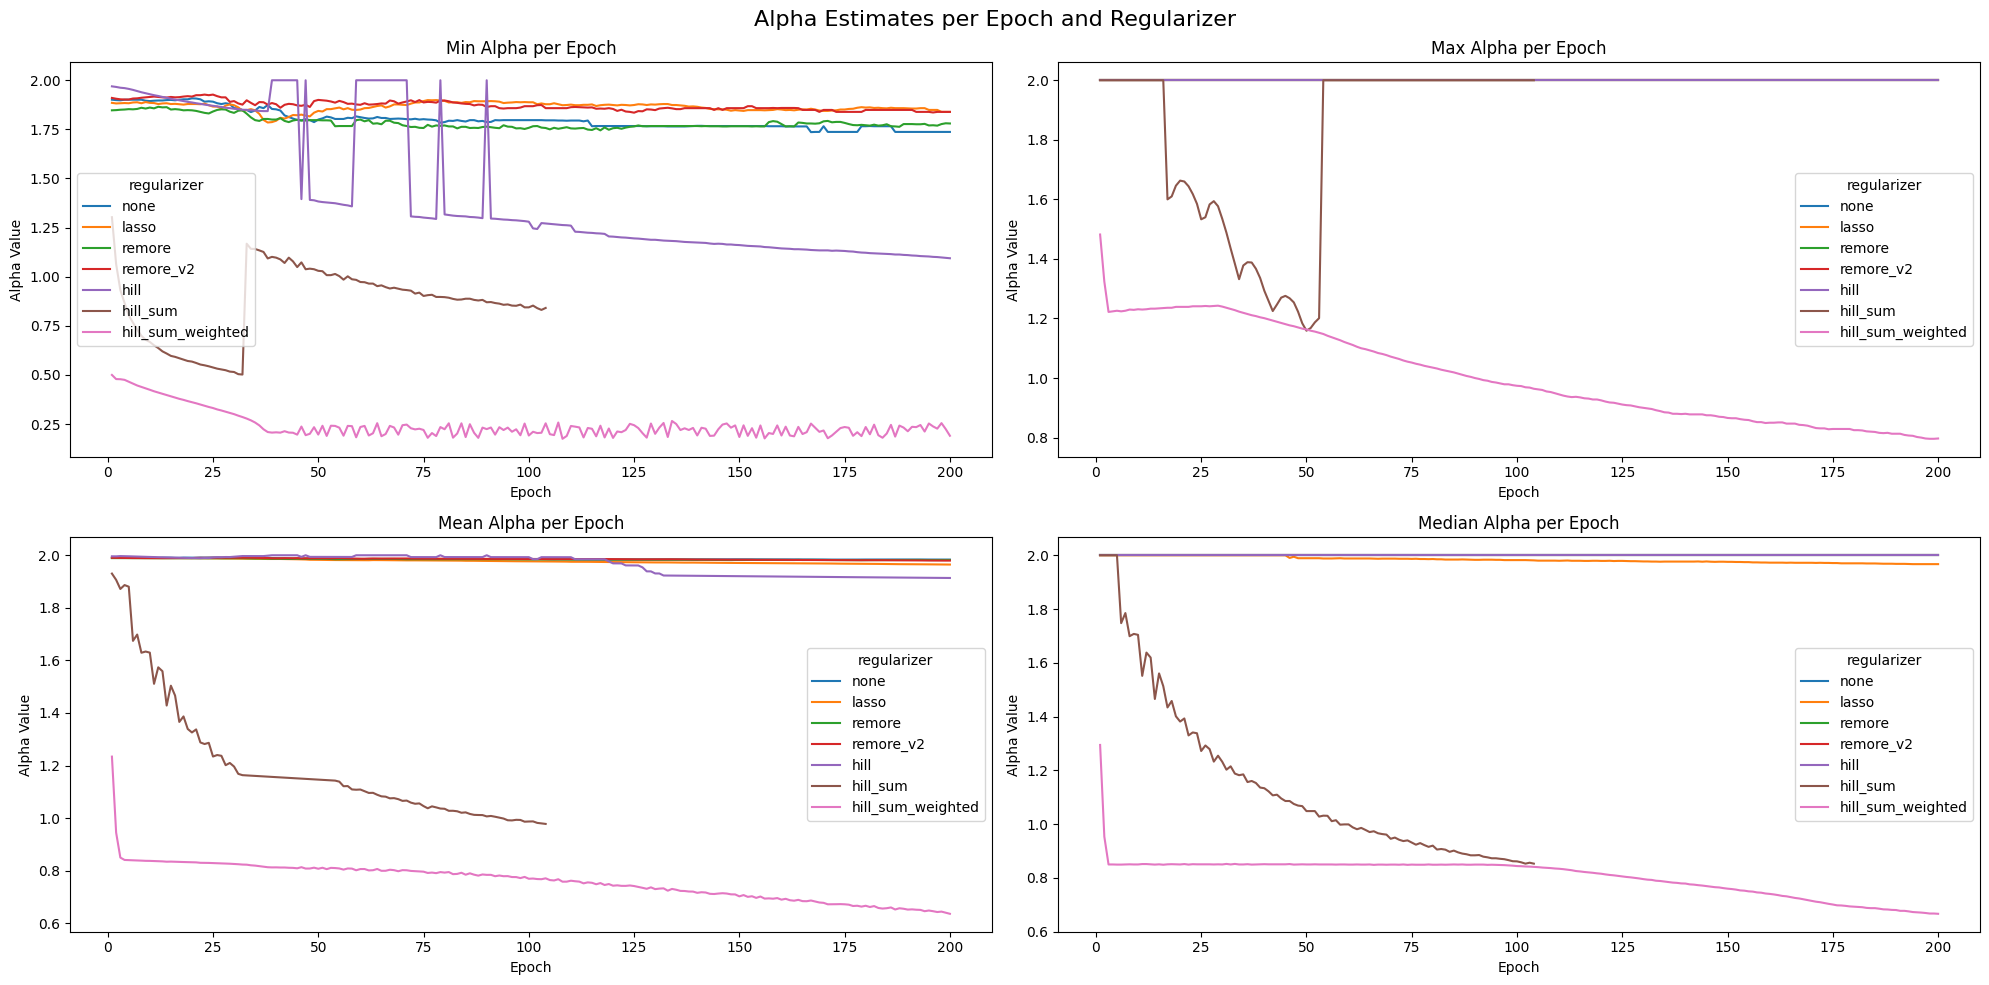

In [25]:
fig,axes = plt.subplots(figsize=(20,10), ncols=2, nrows=2)

sns.lineplot(
    x="epoch", 
    y="alpha_value", 
    hue = "regularizer", 
    data=df_concatenated_epochs[df_concatenated_epochs["statistic"] == "min_alpha"], 
    ax=axes[0,0])

sns.lineplot(
    x="epoch", 
    y="alpha_value", 
    hue = "regularizer", 
    data=df_concatenated_epochs[df_concatenated_epochs["statistic"] == "max_alpha"], 
    ax=axes[0,1])

sns.lineplot(
    x="epoch", 
    y="alpha_value", 
    hue = "regularizer", 
    data=df_concatenated_epochs[df_concatenated_epochs["statistic"] == "mean_alpha"], 
    ax=axes[1,0])

sns.lineplot(
    x="epoch", 
    y="alpha_value", 
    hue = "regularizer", 
    data=df_concatenated_epochs[df_concatenated_epochs["statistic"] == "median_alpha"], 
    ax=axes[1,1])


axes[0,0].set_title("Min Alpha per Epoch")
axes[0,1].set_title("Max Alpha per Epoch")
axes[1,0].set_title("Mean Alpha per Epoch")
axes[1,1].set_title("Median Alpha per Epoch")

for ax_row in axes:
    for ax in ax_row:
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Alpha Value")

fig.suptitle("Alpha Estimates per Epoch and Regularizer", fontsize=16)
fig.tight_layout()  

<h3> Analytisc per Layer </h3>

In [27]:
df_fc10_gaussian_none_sgd_descriptive_layer = df_fc10_gaussian_none_sgd.group_by(["layer", "regularizer"]).agg(
            pl.col("alpha").min().alias("min_alpha"), 
            pl.col("alpha").max().alias("max_alpha"), 
            pl.col("alpha").mean().alias("mean_alpha"),
            pl.col("alpha").median().alias("median_alpha")
        ).sort("layer")  

df_fc10_gaussian_none_sgd_descriptive_layer = df_fc10_gaussian_none_sgd_descriptive_layer.with_columns(pl.lit("none").alias("regularizer"))

df_fc10_gaussian_lasso_sgd_descriptive_layer = df_fc10_gaussian_lasso_sgd.group_by(["layer", "regularizer"]).agg(
            pl.col("alpha").min().alias("min_alpha"), 
            pl.col("alpha").max().alias("max_alpha"), 
            pl.col("alpha").mean().alias("mean_alpha"),
            pl.col("alpha").median().alias("median_alpha")
        ).sort("layer")  

df_fc10_gaussian_lasso_sgd_descriptive_layer = df_fc10_gaussian_lasso_sgd_descriptive_layer.with_columns(pl.lit("lasso").alias("regularizer"))

df_fc10_gaussian_remore_sgd_descriptive_layer = df_fc10_gaussian_remore_sgd.group_by(["layer", "regularizer"]).agg(
            pl.col("alpha").min().alias("min_alpha"), 
            pl.col("alpha").max().alias("max_alpha"), 
            pl.col("alpha").mean().alias("mean_alpha"),
            pl.col("alpha").median().alias("median_alpha")
        ).sort("layer")  

df_fc10_gaussian_remore_sgd_descriptive_layer = df_fc10_gaussian_remore_sgd_descriptive_layer.with_columns(pl.lit("remore").alias("regularizer"))


df_fc10_gaussian_hill_sgd_descriptive_layer = df_fc10_gaussian_hill_sgd.group_by(["layer", "regularizer"]).agg(
            pl.col("alpha").min().alias("min_alpha"), 
            pl.col("alpha").max().alias("max_alpha"), 
            pl.col("alpha").mean().alias("mean_alpha"),
            pl.col("alpha").median().alias("median_alpha")
        ).sort("layer")  

df_fc10_gaussian_hill_sgd_descriptive_layer = df_fc10_gaussian_hill_sgd_descriptive_layer.with_columns(pl.lit("hill").alias("regularizer"))

df_fc10_gaussian_hill_sum_sgd_descriptive_layer = df_fc10_gaussian_hill_sum_sgd.group_by(["layer", "regularizer"]).agg(
            pl.col("alpha").min().alias("min_alpha"), 
            pl.col("alpha").max().alias("max_alpha"), 
            pl.col("alpha").mean().alias("mean_alpha"),
            pl.col("alpha").median().alias("median_alpha")
        ).sort("layer")  

df_fc10_gaussian_hill_sum_sgd_descriptive_layer = df_fc10_gaussian_hill_sum_sgd_descriptive_layer.with_columns(pl.lit("hill_sum").alias("regularizer"))


df_fc10_gaussian_hill_sum_weighted_sgd_descriptive_layer = df_fc10_gaussian_hill_sum_weighted_sgd.group_by(["layer", "regularizer"]).agg(
            pl.col("alpha").min().alias("min_alpha"), 
            pl.col("alpha").max().alias("max_alpha"), 
            pl.col("alpha").mean().alias("mean_alpha"),
            pl.col("alpha").median().alias("median_alpha")
        ).sort("layer")  

df_fc10_gaussian_hill_sum_weighted_sgd_descriptive_layer = df_fc10_gaussian_hill_sum_weighted_sgd_descriptive_layer.with_columns(pl.lit("hill_sum_weighted").alias("regularizer"))

In [28]:
df_concatenated_layers = pl.concat([df_fc10_gaussian_none_sgd_descriptive_layer, df_fc10_gaussian_lasso_sgd_descriptive_layer, df_fc10_gaussian_remore_sgd_descriptive_layer, df_fc10_gaussian_hill_sgd_descriptive_layer, df_fc10_gaussian_hill_sum_sgd_descriptive_layer, df_fc10_gaussian_hill_sum_weighted_sgd_descriptive_layer], how="vertical")

In [29]:
df_concatenated_layers = (
    df_concatenated_layers.unpivot(
        index=["layer", "regularizer"],
        on=["min_alpha", "max_alpha", "mean_alpha", "median_alpha"],
        variable_name="statistic",
        value_name="alpha_value"
    )
).to_pandas()


In [26]:
df_concatenated_layers

,layer,regularizer,statistic,alpha_value
0,layers.0,none,min_alpha,1.976000
1,layers.1,none,min_alpha,1.968000
2,layers.2,none,min_alpha,1.955000
3,layers.3,none,min_alpha,1.971000
4,layers.4,none,min_alpha,1.978000
...,...,...,...,...
195,layers.5,hill_sum,median_alpha,1.446000
196,layers.6,hill_sum,median_alpha,1.440000
197,layers.7,hill_sum,median_alpha,1.445500
198,layers.8,hill_sum,median_alpha,1.442000


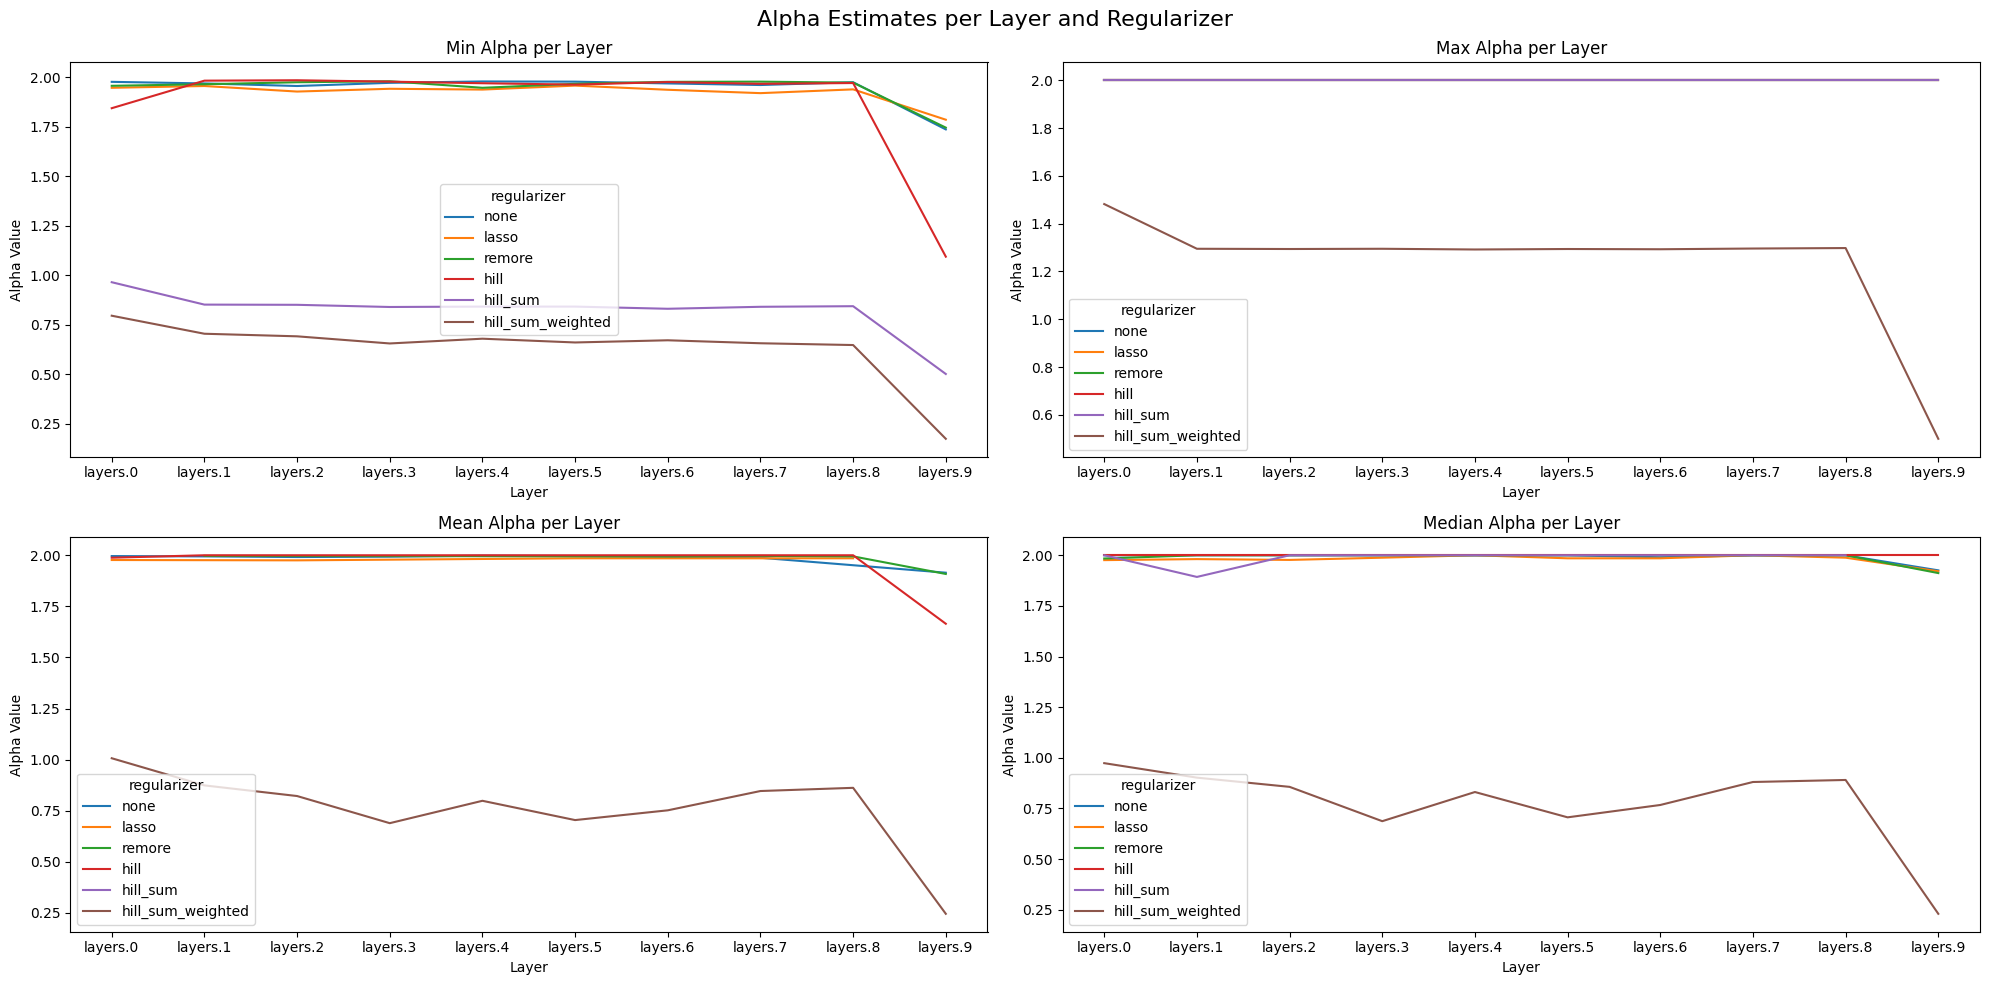

: 

In [ ]:
fig,axes = plt.subplots(figsize=(20,10), ncols=2, nrows=2)

sns.lineplot(
    x="layer", 
    y="alpha_value", 
    hue = "regularizer", 
    data=df_concatenated_layers[df_concatenated_layers["statistic"] == "min_alpha"], 
    ax=axes[0,0])

sns.lineplot(
    x="layer", 
    y="alpha_value", 
    hue = "regularizer", 
    data=df_concatenated_layers[df_concatenated_layers["statistic"] == "max_alpha"], 
    ax=axes[0,1])

sns.lineplot(
    x="layer", 
    y="alpha_value", 
    hue = "regularizer", 
    data=df_concatenated_layers[df_concatenated_layers["statistic"] == "mean_alpha"], 
    ax=axes[1,0])

sns.lineplot(
    x="layer", 
    y="alpha_value", 
    hue = "regularizer", 
    data=df_concatenated_layers[df_concatenated_layers["statistic"] == "median_alpha"], 
    ax=axes[1,1])

axes[0,0].set_title("Min Alpha per Layer")
axes[0,1].set_title("Max Alpha per Layer")
axes[1,0].set_title("Mean Alpha per Layer")
axes[1,1].set_title("Median Alpha per Layer")

for ax_row in axes:
    for ax in ax_row:
        ax.set_xlabel("Layer")
        ax.set_ylabel("Alpha Value")

fig.suptitle("Alpha Estimates per Layer and Regularizer", fontsize=16)
fig.tight_layout()  

In [10]:
from scipy.stats import levy_stable 
import seaborn as sns 
import plotly_express as px
data = levy_stable.rvs(0.5, 0, size = 10000)

px.histogram(data)